# Despliegue del modelo predictivo con interfaz gráfica - Accidentes de Tránsito en Bucaramanga

Modelo: clasificación de la gravedad del accidente (Con víctimas / Solo daños), Comuna Centro, 2017.

Este notebook es la aplicación. Para publicarla se descarga como archivo .py (Archivo > Descargar > Descargar .py) y se le cambia el nombre a `app.py`; por eso todas las celdas son código de Streamlit y no hay celdas de prueba.

1. Configurar la página y el estilo
2. Cargar el modelo guardado en el notebook de modelos
3. Preparar los datos nuevos (mismas transformaciones del entrenamiento)
4. Barra lateral, portada y captura de datos
5. Predicción y resultado
6. Publicación en Streamlit Community Cloud y pantallazo

## 1. Página y estilo

Se configura la página de Streamlit (esto tiene que ser lo primero) y se define el estilo con un poco de CSS: colores, tarjetas y la portada.

In [ ]:
import pickle
from html import escape

import pandas as pd
import streamlit as st

st.set_page_config(page_title="Gravedad de accidentes · Bucaramanga", page_icon="🚦", layout="wide")

In [ ]:
ASFALTO, AMARILLO, ROJO, VERDE = "#1E2A32", "#F2B705", "#C8453B", "#2F8F6B"

st.markdown(
    f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Barlow:wght@400;500;600&family=Barlow+Condensed:wght@600;700&display=optional');

html, body, .stApp, [data-testid="stSidebar"] {{ font-family: 'Barlow', 'Segoe UI', sans-serif; }}
.stApp {{ background: #ECEEEF; }}
.stApp p, .stApp label, .stApp li, .stApp span, .stApp div[data-testid="stWidgetLabel"] p {{ color: {ASFALTO}; }}
[data-testid="stHeader"] {{ background: transparent; }}
footer {{ visibility: hidden; }}
.block-container {{ max-width: 1120px; padding-top: 1.2rem; padding-bottom: 3rem; }}

/* Portada: una calzada con su línea central */
.hero {{ background: {ASFALTO}; border-radius: 18px; padding: 2.6rem 2.6rem 3.4rem; position: relative; overflow: hidden; margin-bottom: 1.6rem; }}
.hero .titulo {{ font-family: 'Barlow Condensed', 'Arial Narrow', sans-serif; font-weight: 700; font-size: 3.3rem; line-height: 1.02;
            color: #FFFFFF !important; margin: 0 0 .8rem; padding: 0; letter-spacing: .2px; }}
.hero p {{ color: #C9D1D6 !important; font-size: 1.08rem; line-height: 1.5; max-width: 620px; margin: 0; }}
.hero .centerline {{ position: absolute; left: 0; right: 0; bottom: 22px; height: 5px;
    background: repeating-linear-gradient(90deg, {AMARILLO} 0 44px, transparent 44px 76px); }}

/* Tarjetas */
[data-testid="stVerticalBlock"]:has(> [data-testid="stElementContainer"] .card-title),
[data-testid="stVerticalBlockBorderWrapper"] {{ background: #FFFFFF; border: 1px solid #DDE1E4 !important; border-radius: 16px; padding: .6rem 1rem 1rem; }}
[data-testid="stExpander"] {{ margin-top: .9rem; background: #FFFFFF; border-radius: 12px; }}
.card-title {{ font-family: 'Barlow Condensed', 'Arial Narrow', sans-serif; font-weight: 700; font-size: 1.65rem; color: {ASFALTO}; margin: .3rem 0 .1rem; }}
.card-sub {{ color: #5B6770 !important; font-size: .95rem; margin-bottom: .8rem; }}

/* Controles */
[data-baseweb="slider"] [role="slider"] {{ background: {ASFALTO} !important; border: 3px solid {AMARILLO} !important; }}
div[data-baseweb="select"] > div {{ border-radius: 10px; }}

/* Resultado */
.res {{ background: #FFFFFF; border: 1px solid #DDE1E4; border-left: 10px solid var(--c); border-radius: 16px; padding: 1.5rem 1.7rem 1.4rem; }}
.res-title {{ font-family: 'Barlow Condensed', 'Arial Narrow', sans-serif; font-weight: 700; font-size: 3.6rem; line-height: 1; color: var(--c) !important; }}
.res-sub {{ font-size: 1.1rem; margin: .5rem 0 1.3rem; color: {ASFALTO} !important; }}
.lane {{ display: flex; height: 46px; border-radius: 10px; overflow: hidden; background: #E3E6E8; }}
.seg {{ display: flex; align-items: center; justify-content: center; color: #FFFFFF !important; font-weight: 600; font-size: 1.05rem; min-width: 0; transition: width .35s ease; }}
.lane-legend {{ display: flex; gap: 1.4rem; margin-top: .55rem; font-size: .92rem; color: #5B6770 !important; }}
.lane-legend i {{ display: inline-block; width: 11px; height: 11px; border-radius: 3px; margin-right: 6px; vertical-align: -1px; }}
.res-note {{ margin-top: 1.1rem; padding-top: .9rem; border-top: 1px dashed #C9D1D6; font-size: .98rem; color: #3E4A53 !important; }}
.chips {{ display: flex; flex-wrap: wrap; gap: .5rem; margin-top: 1rem; }}
.chip {{ background: #F1F3F4; border: 1px solid #DDE1E4; border-radius: 999px; padding: .25rem .8rem; font-size: .9rem; color: {ASFALTO} !important; }}

/* Barra lateral */
[data-testid="stSidebar"] {{ background: #FFFFFF; border-right: 1px solid #DDE1E4; }}
.side-title {{ font-family: 'Barlow Condensed', 'Arial Narrow', sans-serif; font-weight: 700; font-size: 1.5rem; color: {ASFALTO}; margin-bottom: .2rem; }}
.metric {{ background: #F5F6F7; border-radius: 12px; padding: .7rem .9rem; margin: .5rem 0; }}
.metric b {{ font-family: 'Barlow Condensed', 'Arial Narrow', sans-serif; font-size: 1.9rem; display: block; line-height: 1.05; color: {ASFALTO} !important; }}
.metric span {{ font-size: .88rem; color: #5B6770 !important; }}

@media (max-width: 720px) {{
  .hero {{ padding: 1.8rem 1.4rem 2.8rem; }}
  .hero .titulo {{ font-size: 2.3rem; }}
  .res-title {{ font-size: 2.6rem; }}
}}
</style>
""",
    unsafe_allow_html=True,
)

## 2. Cargar el modelo

Primero los nombres que se muestran en la interfaz para cada variable (si una variable no está en la lista, se muestra con su nombre) y los colores de cada clase.

In [ ]:
# Etiquetas amigables (si una variable no está aquí, se muestra su nombre)
ETIQUETAS = {
    "Mes": "Mes",
    "Dia": "Día de la semana",
    "Hora": "Hora del día (0-23)",
    "Jornada": "Jornada",
    "Barrio": "Barrio",
    "Propietario": "Propietario del vehículo",
    "Automovil": "Automóviles involucrados",
    "Moto": "Motos involucradas",
    "Peaton": "Peatones involucrados",
    "Camioneta": "Camionetas involucradas",
    "Buseta": "Busetas involucradas",
    "Camion": "Camiones involucrados",
}
COLORES = {"Con víctimas": ROJO, "Solo daños": VERDE}
FRASES = {
    "Con víctimas": "El modelo estima que este accidente dejaría heridos o fallecidos.",
    "Solo daños": "El modelo estima que este accidente solo dejaría daños materiales.",
}

Después se lee el `.pkl` que guardó el notebook de modelos: el modelo, el LabelEncoder, las columnas con las que se entrenó y la información de las variables de entrada (rangos y categorías). `@st.cache_resource` hace que se cargue una sola vez. Si la carga falla, la app muestra el error y las versiones de las librerías, porque Streamlit Cloud oculta el mensaje por defecto.

In [ ]:
@st.cache_resource
def cargar_modelo(ruta="modelo-class-accidentes.pkl"):
    with open(ruta, "rb") as f:
        return pickle.load(f)


try:
    artefactos = cargar_modelo()
except Exception as e:   # muestra el error real (Streamlit Cloud lo oculta por defecto)
    import sys, sklearn, numpy
    st.error(f"No se pudo cargar el modelo: {type(e).__name__}: {e}")
    st.code(
        f"Python {sys.version.split()[0]}\n"
        f"scikit-learn=={sklearn.__version__}\n"
        f"pandas=={pd.__version__}\n"
        f"numpy=={numpy.__version__}"
    )
    st.stop()

modelo = artefactos["modelo"]
labelencoder = artefactos["labelencoder"]
variables = artefactos["variables"]      # columnas (dummies) con las que se entrenó el modelo
info = artefactos["info"]                # variables de entrada, rangos y categorías
metricas = info.get("metricas_cv") or {}

## 3. Preparación de datos nuevos

Los datos que se escriben en la interfaz tienen que pasar por las mismas transformaciones del entrenamiento:

* Dummies con las categorías del entrenamiento (se fijan con `pd.Categorical`; si no, con una sola fila `get_dummies` no sabe qué categorías existen).
* `reindex` con las columnas guardadas: deja exactamente las columnas del entrenamiento y descarta la categoría de referencia (`drop_first=True`).
* Si el modelo se entrenó con las numéricas normalizadas (KNN, red neuronal o SVM) se normalizan con el scaler guardado. El Random Forest no lo necesita, así que aquí no se aplica.

In [ ]:
def preparar(datos):
    datos = datos.copy()
    # Se fijan las categorías del entrenamiento para que el dummy de una sola fila sea correcto
    for col, categorias in info["categoricas"].items():
        datos[col] = pd.Categorical(datos[col], categories=categorias)
    preparada = pd.get_dummies(datos, columns=list(info["categoricas"]), dtype=int)
    # Se dejan exactamente las columnas del entrenamiento (la categoría de referencia queda fuera)
    preparada = preparada.reindex(columns=variables, fill_value=0)
    # Solo si el modelo final se entrenó con las variables numéricas normalizadas (KNN, red neuronal, SVM)
    if info.get("usa_escalado"):
        columnas = list(info["numericas"])
        preparada[columnas] = artefactos["scaler"].transform(preparada[columnas])
    return preparada


def predecir(datos):
    preparada = preparar(datos)
    clase = labelencoder.inverse_transform(modelo.predict(preparada))
    proba = modelo.predict_proba(preparada)
    return clase, proba

## 4. Barra lateral, portada y captura de datos

La barra lateral muestra el algoritmo y las medidas de la validación cruzada. Los controles de la izquierda se arman con la información guardada en el modelo (variables, rangos y categorías), así que no hay que editarlos si cambian las variables.

In [ ]:
with st.sidebar:
    st.markdown('<div class="side-title">Sobre el modelo</div>', unsafe_allow_html=True)
    st.write(f"Algoritmo: **{info.get('nombre_modelo', 'modelo')}**, ajustado con GridSearch y validación cruzada de 10 pliegues.")
    if metricas:
        st.markdown(
            f'<div class="metric"><b>{metricas["f1_macro"]:.2f}</b><span>F1 macro en validación cruzada</span></div>'
            f'<div class="metric"><b>{metricas["accuracy"]:.2f}</b><span>Exactitud en validación cruzada</span></div>',
            unsafe_allow_html=True,
        )
    usadas = ", ".join(ETIQUETAS.get(c, c).lower() for c in info["columnas_entrada"])
    st.write(f"**Factores que usa:** {usadas}.")
    st.write("**Datos:** accidentes de la Comuna Centro de Bucaramanga en 2017, reportados por la Secretaría de Tránsito.")
    st.caption("Es una herramienta de apoyo para analizar patrones. No reemplaza el criterio de un experto.")

In [ ]:
st.markdown(
    '<div class="hero"><div class="titulo">¿Qué tan grave será el accidente?</div>'
    "<p>Un modelo de clasificación entrenado con accidentes de tránsito de la Comuna Centro de Bucaramanga. "
    "Cambia los datos de la izquierda y mira cómo se mueve la predicción.</p>"
    '<div class="centerline"></div></div>',
    unsafe_allow_html=True,
)

izq, der = st.columns([5, 6], gap="large")

In [ ]:
entradas = {}
with izq:
    with st.container(border=True):
        st.markdown('<div class="card-title">Datos del accidente</div>'
                    '<div class="card-sub">Describe lo que se sabe del siniestro.</div>', unsafe_allow_html=True)
        for col in info["columnas_entrada"]:
            etiqueta = ETIQUETAS.get(col, col)
            if col in info["numericas"]:
                minimo, maximo = info["numericas"][col]
                if minimo < maximo:
                    entradas[col] = st.slider(etiqueta, min_value=minimo, max_value=maximo, value=minimo, step=1)
                else:
                    entradas[col] = st.number_input(etiqueta, value=minimo)
            else:
                entradas[col] = st.selectbox(etiqueta, info["categoricas"][col])

## 5. Predicción y resultado

Con los valores de los controles se arma un dataframe de una fila, se predice la clase y la probabilidad de cada una, y se muestra el resultado con una barra de colores. Según qué tan alta es la probabilidad se indica si la señal es fuerte, moderada o débil.

In [ ]:
datos = pd.DataFrame([entradas])[info["columnas_entrada"]]
clase, probabilidades = predecir(datos)
prediccion = clase[0]
proba = dict(zip(labelencoder.classes_, probabilidades[0]))
confianza = proba[prediccion]

if confianza >= 0.75:
    nota = "Señal fuerte: con estos datos el modelo se inclina con claridad hacia una de las dos clases."
elif confianza >= 0.60:
    nota = "Señal moderada: el modelo prefiere una clase, pero la otra sigue siendo posible."
else:
    nota = "Señal débil: con estos datos el modelo casi no distingue entre las dos clases. Conviene no darle mucho peso."

In [ ]:
color = COLORES.get(prediccion, ASFALTO)
segmentos = "".join(
    f'<div class="seg" style="width:{p * 100:.1f}%;background:{COLORES.get(c, "#7A8791")}">'
    f'{p * 100:.0f}%</div>' if p >= 0.08 else
    f'<div class="seg" style="width:{p * 100:.1f}%;background:{COLORES.get(c, "#7A8791")}"></div>'
    for c, p in proba.items()
)
leyenda = "".join(
    f'<span><i style="background:{COLORES.get(c, "#7A8791")}"></i>{escape(str(c))}</span>' for c in proba
)
chips = "".join(
    f'<span class="chip">{escape(str(v))} {escape(ETIQUETAS.get(k, k).lower())}</span>'
    if k in info["numericas"] else f'<span class="chip">{escape(str(v))}</span>'
    for k, v in entradas.items()
)

with der:
    st.markdown(
        f'<div class="res" style="--c:{color}">'
        f'<div class="res-title">{escape(str(prediccion))}</div>'
        f'<div class="res-sub">{escape(FRASES.get(prediccion, ""))} Confianza del modelo: <b>{confianza * 100:.0f}%</b>.</div>'
        f'<div class="lane">{segmentos}</div>'
        f'<div class="lane-legend">{leyenda}</div>'
        f'<div class="res-note">{nota}</div>'
        f'<div class="chips">{chips}</div>'
        f"</div>",
        unsafe_allow_html=True,
    )
    with st.expander("Cómo leer este resultado"):
        st.write(
            "La barra muestra la probabilidad que el modelo le asigna a cada clase; siempre suman 100%. "
            "Cuanto más se acerque al 50/50, menos información tiene el modelo para decidir."
        )
        st.write(
            "El modelo solo conoce los factores de la barra lateral y fue entrenado con unos 400 accidentes "
            "de una comuna y un año, por lo que no debe usarse para otras zonas o épocas."
        )

## 6. Publicación en Streamlit Community Cloud

La aplicación está publicada en Streamlit Community Cloud y conectada al repositorio de GitHub del proyecto:

* Aplicación: https://despliegue-accidentes-bucaramanga-tyeafamwxu26vsiyjqegrs.streamlit.app
* Repositorio: https://github.com/santymaya9/Despliegue-Accidentes-Bucaramanga

En la raíz del repositorio están `app.py` (este notebook descargado como .py), `modelo-class-accidentes.pkl`, `requirements.txt` y `.streamlit/config.toml`.

## Pantallazo del despliegue


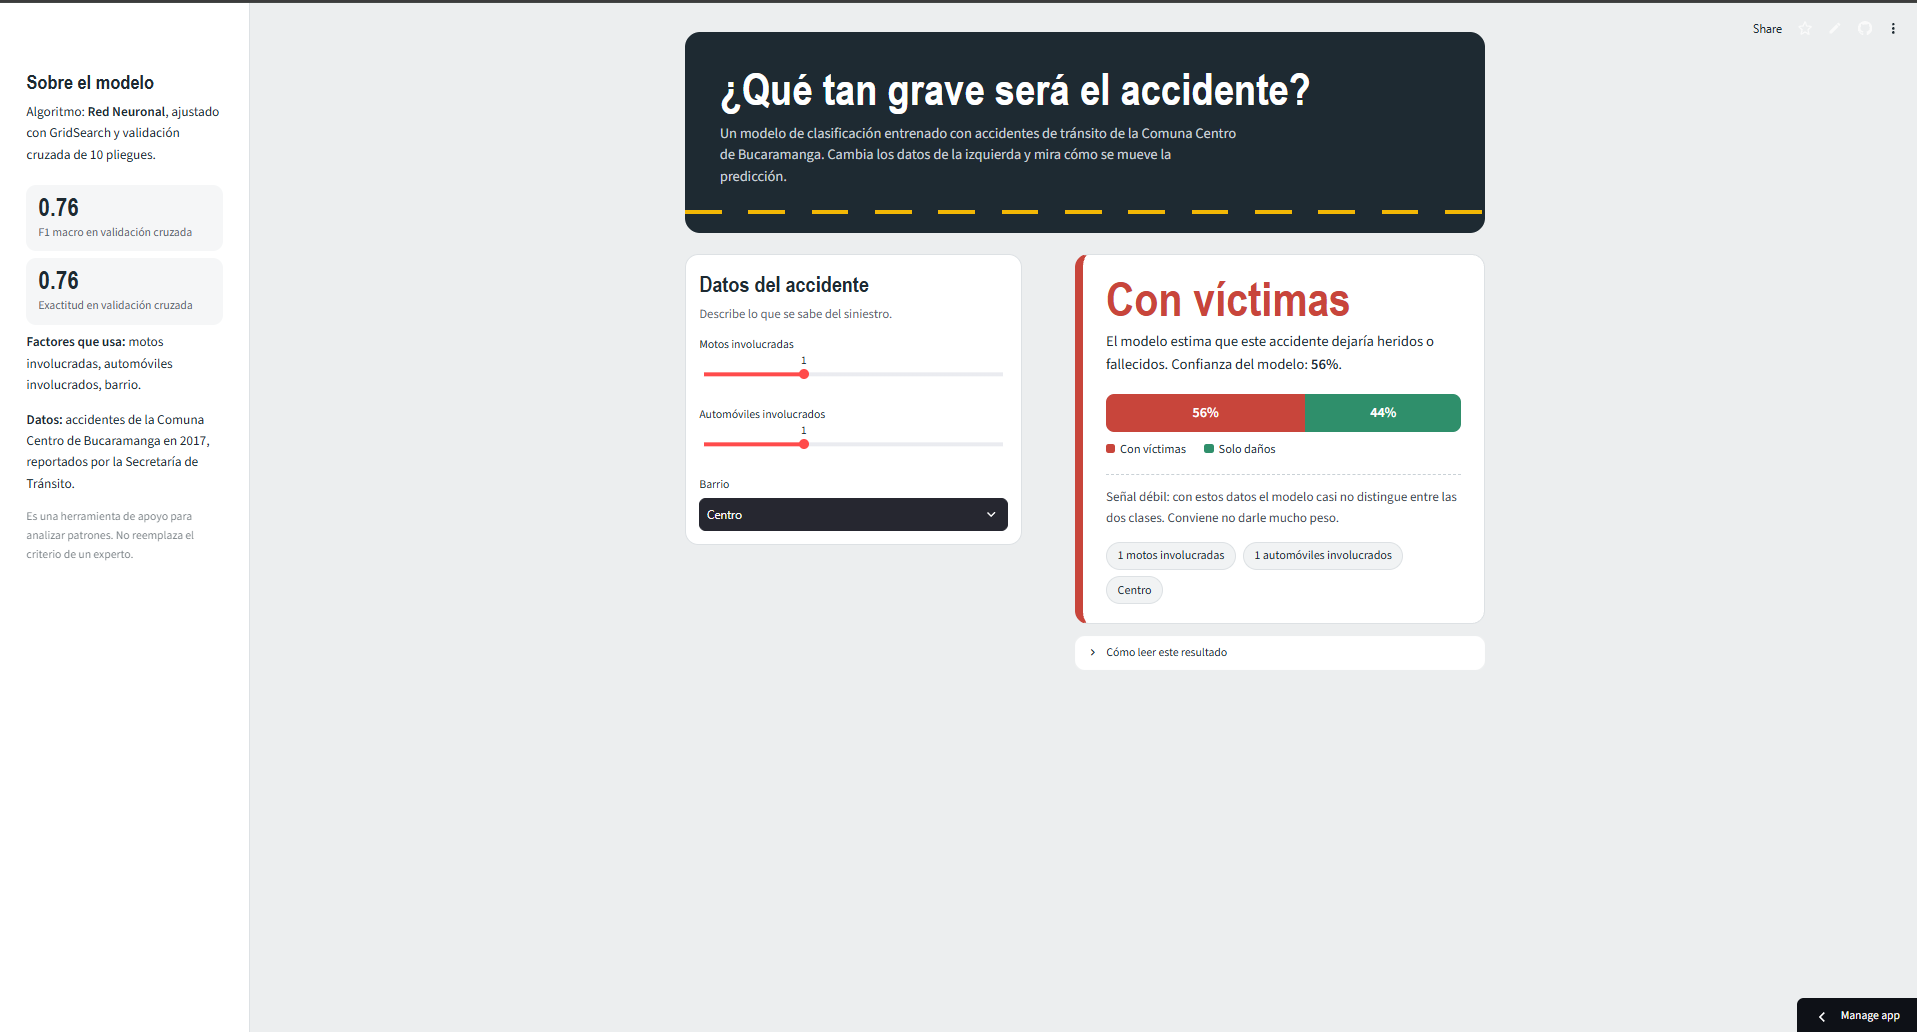